In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [2]:
transform = transforms.Compose([
    transforms.Resize((47, 47)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)


class_names = ['0','1','2','3','4','5','6','7','8','9']

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


In [3]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.c1 = nn.Conv2d(1,32,2) # 46->23
    self.pool = nn.MaxPool2d(2,2)
    self.c2 = nn.Conv2d(32,64,2) # 22-> 11
    self.c3 = nn.Conv2d(64,128,2) # 11->10

    self.fc1 = nn.Linear(128*10*10, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64,32)
    self.fc4 = nn.Linear(32,10)


  def forward(self,x):
    x = self.pool(F.relu(self.c1(x)))
    x = self.pool(F.relu(self.c2(x)))
    x = F.relu(self.c3(x))
    x = torch.flatten(x,1)

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)

    return x





modal = NeuralNetwork()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(modal.parameters(), lr=0.0001)


In [4]:
losses = []

for epoch in range(10):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = modal(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/10  Loss: {epoch_loss:.4f}")

Epoch 1/10  Loss: 0.4113
Epoch 2/10  Loss: 0.1338
Epoch 3/10  Loss: 0.0826
Epoch 4/10  Loss: 0.0623
Epoch 5/10  Loss: 0.0491
Epoch 6/10  Loss: 0.0400
Epoch 7/10  Loss: 0.0325
Epoch 8/10  Loss: 0.0268
Epoch 9/10  Loss: 0.0231
Epoch 10/10  Loss: 0.0185


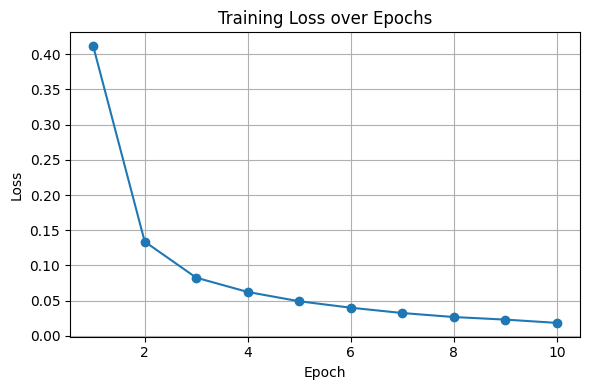

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
torch.save(modal.state_dict(), 'MNIST_MODAL.pth')
modal.load_state_dict(torch.load('MNIST_MODAL.pth'))

modal.eval()


correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images, labels = data
    outputs = modal(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()



acc = (correct/total)*100
print(f'Accuracy : {acc:0.2f}%')

Accuracy : 98.68%


 Passed 


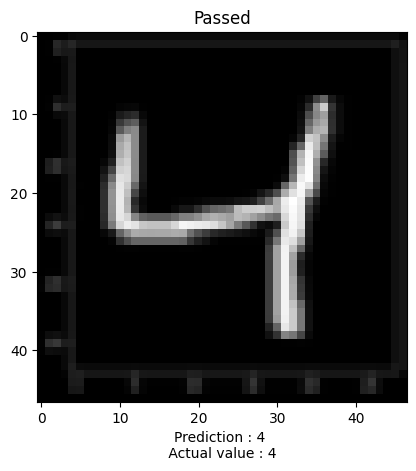




------------------------------------------------------- 

 Passed 


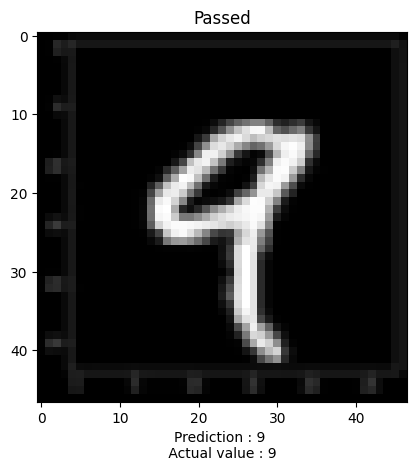




------------------------------------------------------- 

 Failed 


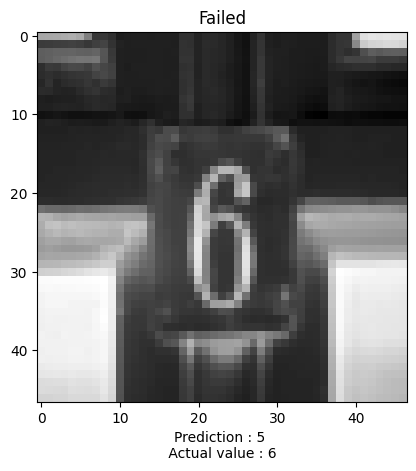




------------------------------------------------------- 



In [21]:
new_transform = transforms.Compose([
    transforms.Resize((47,47)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x), # Invert colors to match MNIST (white digit on black background)
    transforms.Normalize((0.5,), (0.5,))
])



image_paths = ["/MNIST/4.jpg", "/MNIST/9.jpg", "/MNIST/6.jpg"]
actual_labels = ["4", "9", "6"]

for i in range(len(image_paths)):

    image_path = f'/content/data/{image_paths[i]}'
    image = Image.open(image_path)
    image = new_transform(image)
    image = image.unsqueeze(0)


    output = modal(image)
    _, prediction = torch.max(output.data, 1)

    if(class_names[prediction] == actual_labels[i]):
      print('\033[92m Passed \033[0m')
      plt.title('Passed')
    else:
      print('\033[91m Failed \033[0m')
      plt.title('Failed')

    # Denormalize and reorder dimensions for matplotlib display
    display_image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    display_image = display_image * 0.5 + 0.5 # Denormalize
    plt.imshow(display_image, cmap='gray') # Add cmap='gray' for grayscale images
    plt.xlabel(f'Prediction : {class_names[prediction]} \n Actual value : {actual_labels[i]} ')
    plt.show() # Display each image separately

    print("\n")


    print("\n------------------------------------------------------- \n")